In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
USREDNIANIE = 2

df = pd.read_csv("start.csv", delimiter=";")
df["TIMESTAMP"] -= df["TIMESTAMP"][0]
df["TIMESTAMP"] /= 1000
df["TANK_PRESS"] /= 100
df["TANK_D_PRESS"] /= 100
df["TANK_D_PRESS"] = df["TANK_D_PRESS"].rolling(USREDNIANIE).mean()
df["TANK_PRESS"] = df["TANK_PRESS"].rolling(USREDNIANIE).mean()

df = df[df["TIMESTAMP"] > 210.5]
df["TIMESTAMP"] -= 210.5
df.head()

,TIMESTAMP,TEMP1,TEMP2,TEMP3,TANK_PRESS,TANK_D_PRESS,CPU_USAGE,MEM_USAGE,DISK_UTILIZATION,TENSO
35751,0.033,177,155,0,51.620,1.420,100.0,7.79,63.0,0.0
35752,0.039,177,155,0,51.400,1.220,100.0,7.79,63.0,0.0
35753,0.044,177,155,0,51.400,1.205,100.0,7.79,63.0,0.0
35754,0.050,177,155,0,51.385,1.490,100.0,7.79,63.0,0.0
35755,0.056,177,155,0,51.370,1.270,100.0,7.79,63.0,0.0


# Ogólny wykres ciągu w teście

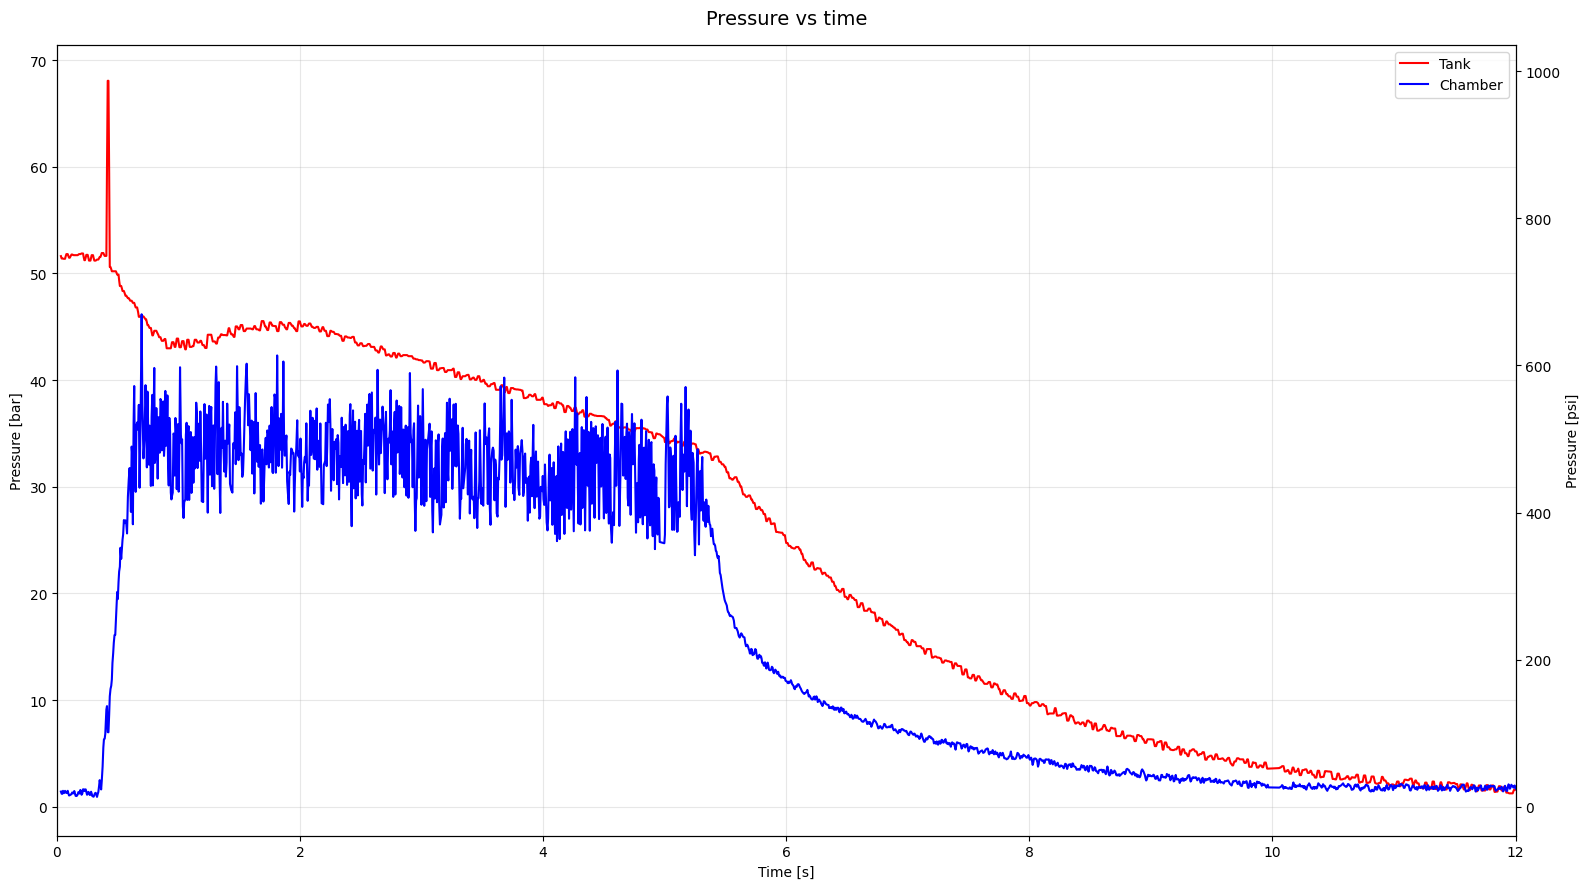

In [10]:
import matplotlib.pyplot as plt

# Współczynnik konwersji: 1 bar = 14.5038 psi
BAR_TO_PSI = 14.5038

fig, ax1 = plt.subplots(figsize=(16, 9))


# Plotowanie danych na pierwszej osi (lewa - bar)
line1, = ax1.plot(df["TIMESTAMP"], df["TANK_PRESS"], label="Tank", color='r', linewidth=1.5)
line2, = ax1.plot(df["TIMESTAMP"], df["TANK_D_PRESS"], label="Chamber", color='b', linewidth=1.5)

# Konfiguracja lewej osi Y i osi X
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Pressure [bar]")
ax1.set_xlim(0, 12) # Zakres w sekundach: 81s - 95s
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

y_min, y_max = ax1.get_ylim()
ax2.set_ylim(y_min * BAR_TO_PSI, y_max * BAR_TO_PSI)
ax2.set_ylabel("Pressure [psi]")

# Tytuł wykresu
plt.title("Pressure vs time", pad=15, fontsize=14)

# Legenda (zbieramy etykiety z obu linii narysowanych na ax1)
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', frameon=True)

plt.tight_layout()
plt.savefig("../../charts/static_10_04_2026.png", dpi=600)
plt.show()

# Przybliżenie na oscylacje

In [35]:
df2 = pd.read_csv("start.csv", delimiter=";")
df2["TIMESTAMP"] -= df2["TIMESTAMP"][0]
df2["TANK_PRESS"] /= 100
df2["TANK_D_PRESS"] /= 100
df2.head()

,TIMESTAMP,TEMP1,TEMP2,TEMP3,TANK_PRESS,TANK_D_PRESS,CPU_USAGE,MEM_USAGE,DISK_UTILIZATION,TENSO
0,0,180,177,0,51.87,1.02,100.0,7.78,62.7,0.0
1,6,180,177,0,52.28,1.42,100.0,7.78,62.7,0.0
2,11,180,177,0,52.28,1.02,100.0,7.78,62.7,0.0
3,16,180,177,0,52.28,1.55,100.0,7.78,62.7,0.0
4,22,180,177,0,52.28,1.55,100.0,7.78,62.7,0.0


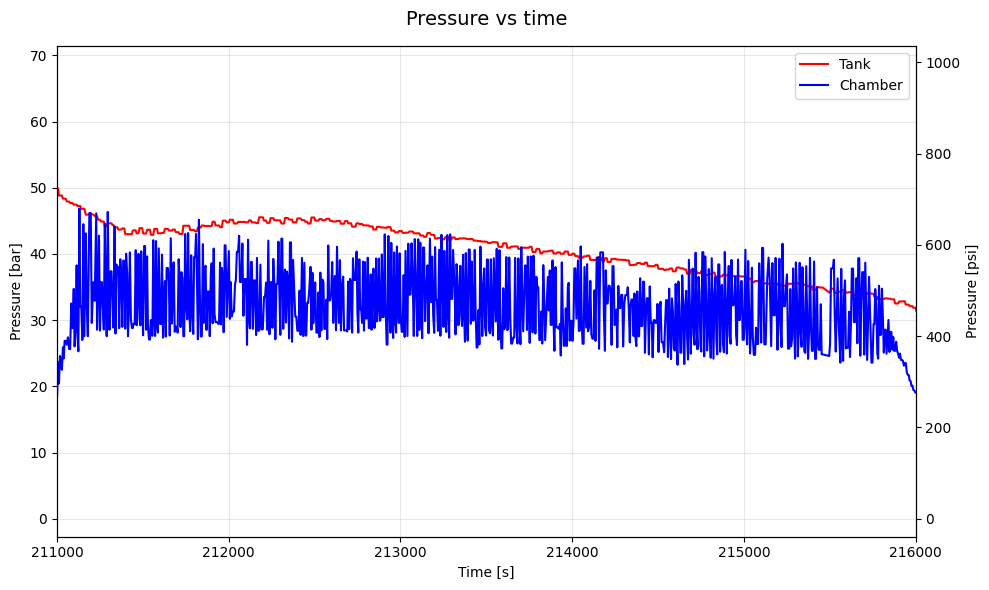

In [43]:
import matplotlib.pyplot as plt

# Współczynnik konwersji: 1 bar = 14.5038 psi
BAR_TO_PSI = 14.5038

fig, ax1 = plt.subplots(figsize=(10, 6))


# Plotowanie danych na pierwszej osi (lewa - bar)
line1, = ax1.plot(df2["TIMESTAMP"], df2["TANK_PRESS"], label="Tank", color='r', linewidth=1.5)
line2, = ax1.plot(df2["TIMESTAMP"], df2["TANK_D_PRESS"], label="Chamber", color='b', linewidth=1.5)

# Konfiguracja lewej osi Y i osi X
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Pressure [bar]")
ax1.set_xlim(211000, 216000) # Zakres w sekundach: 81s - 95s
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

y_min, y_max = ax1.get_ylim()
ax2.set_ylim(y_min * BAR_TO_PSI, y_max * BAR_TO_PSI)
ax2.set_ylabel("Pressure [psi]")

# Tytuł wykresu
plt.title("Pressure vs time", pad=15, fontsize=14)

# Legenda (zbieramy etykiety z obu linii narysowanych na ax1)
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', frameon=True)

plt.tight_layout()
plt.savefig("../../charts/zoom_static_12_03_2026.png")
plt.show()